# SIGNAL PROCESSING OF FREQUENCY MODULATED CONTINOUS WAVE RADAR

Ground truth ranges (m): [30. 80.]
Estimated ranges (m) from peaks: [74.999 74.999 75.003 74.983 75.032 74.921]
Estimated beat freqs (Hz): [ 99999.1  99998.1 100004.5  99977.4 100042.1  99895. ]


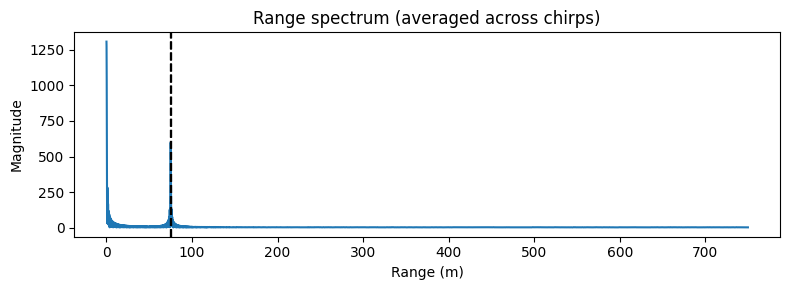

In [ ]:
"""
fmcw_processing.py
Script untuk memproses dataset FMCW yang disimpan di fmcw_simulation_data.npz
Langkah:
- load dataset (.npz)
- hitung beat real, lakukan range-FFT per chirp
- averaging spektrum across chirps (incoherent average)
- cari puncak (abaikan DC/very-low-freq)
- lakukan interpolasi puncak (quadratic) untuk sub-bin accuracy
- hitung PSD (Welch) dan terapkan FIR low-pass (jika scipy tersedia gunakan firwin)
"""
import numpy as np
from pathlib import Path
try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None

data = np.load("fmcw_simulation_data.npz", allow_pickle=True)
t = data["t"]
tx = data["tx"]
rx = data["rx"]
beat = data["beat"]
fs = float(data["fs"])
B = float(data["B"])
T = float(data["T"])
f0 = float(data["f0"])
R_targets = data["R_targets"]

M, N = beat.shape
# use real part (ADC after downconversion often samples real)
beat_real = np.real(beat)

# perform range FFT per chirp and average magnitude (incoherent average)
nfft = 2**14
S_accum = np.zeros(nfft//2, dtype=float)
for m in range(M):
    S = np.fft.fft(beat_real[m], nfft)
    S_mag = np.abs(S[:nfft//2])
    S_accum += S_mag
S_mean = S_accum / M

# frequency and range axis
f_axis = np.fft.fftfreq(nfft, 1/fs)[:nfft//2]
range_axis = f_axis * 3e8 * T / (2*B)

# ignore DC and very low freq when searching peaks
f_min_ignore = 1e3  # 1 kHz
idx_search = np.where(f_axis >= f_min_ignore)[0]

# find top peaks
topk = 6
sorted_idx = np.argsort(S_mean[idx_search])[-topk:][::-1]
peak_bins = idx_search[sorted_idx]

# quadratic interpolation for sub-bin peak location
def quadratic_interpolation(mag, k):
    # fit parabola to (k-1, k, k+1) points and find vertex offset
    if k<=0 or k>=len(mag)-1:
        return k, mag[k]
    alpha = mag[k-1]
    beta = mag[k]
    gamma = mag[k+1]
    denom = (alpha - 2*beta + gamma)
    if denom == 0:
        return k, beta
    delta = 0.5 * (alpha - gamma) / denom
    peak_loc = k + delta
    # estimated magnitude via parabola vertex formula
    peak_mag = beta - 0.25*(alpha - gamma)*delta
    return peak_loc, peak_mag

est_ranges = []
est_freqs = []
est_mags = []
for b in peak_bins:
    pk_loc, pk_mag = quadratic_interpolation(S_mean, b)
    est_freq = f_axis[int(np.round(pk_loc))] if pk_loc < len(f_axis) else f_axis[-1]
    # better: interpolate frequency using fractional bin offset
    est_freq = (pk_loc) * (fs / nfft)
    est_range = est_freq * 3e8 * T / (2*B)
    est_ranges.append(est_range)
    est_freqs.append(est_freq)
    est_mags.append(pk_mag)

# PSD (Welch) if scipy available else simple periodogram-average
try:
    from scipy.signal import welch, firwin, lfilter
    f_welch, Pxx = welch(beat_real.mean(axis=0), fs=fs, nperseg=1024)
    use_scipy = True
except Exception:
    use_scipy = False
    nfft_p = 2**14
    win = np.hanning(N)
    S_per = np.fft.fft(beat_real.mean(axis=0)*win, nfft_p)
    f_welch = np.fft.fftfreq(nfft_p, 1/fs)[:nfft_p//2]
    Pxx = (np.abs(S_per[:nfft_p//2])**2) / (fs * N)

# simple FIR low-pass design (fallback if scipy missing)
def design_fir_lowpass(numtaps, fc_norm):
    M = numtaps - 1
    n = np.arange(0, numtaps)
    h = np.sinc(2 * fc_norm * (n - M/2))
    h *= np.hamming(numtaps)
    h /= np.sum(h)
    return h

# determine cutoff a bit above highest expected beat of targets
expected_max_freq = (2 * max(R_targets) * B) / (3e8 * T)  # approx inverse of formula
f_cut = 1.5 * expected_max_freq
fc_norm = f_cut / (fs/2)
numtaps = 129
if use_scipy:
    h = firwin(numtaps, f_cut, fs=fs, window="hamming", pass_zero=True)
    beat_filt = lfilter(h, 1.0, beat_real.mean(axis=0))
else:
    h = design_fir_lowpass(numtaps, fc_norm)
    beat_filt = np.convolve(beat_real.mean(axis=0), h, mode="same")

# FFT of filtered beat for visualization
S_filt = np.abs(np.fft.fft(beat_filt, nfft)[:nfft//2])

# Save processed results
out = {
    "f_axis": f_axis, "range_axis": range_axis, "S_mean": S_mean,
    "peak_bins": peak_bins, "est_ranges": np.array(est_ranges),
    "est_freqs": np.array(est_freqs), "f_welch": f_welch, "Pxx": Pxx,
    "S_filt": S_filt, "h": h
}
np.savez("fmcw_processing_results.npz", **out)

# Print summary
print("Ground truth ranges (m):", R_targets)
print("Estimated ranges (m) from peaks:", np.round(est_ranges,3))
print("Estimated beat freqs (Hz):", np.round(est_freqs,1))
 
# Optional plotting if matplotlib is available
if plt is not None:
    plt.figure(figsize=(8,3))
    plt.plot(range_axis, S_mean)
    plt.title("Range spectrum (averaged across chirps)")
    plt.xlabel("Range (m)")
    plt.ylabel("Magnitude")
    for r in est_ranges:
        plt.axvline(r, color="k", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()


Ground truth ranges (m): [30. 80.]
Estimated ranges (m):    [74.999 74.999 75.003 74.983 75.032 74.921]
Estimated beat freqs (Hz): [ 99999.1  99998.1 100004.5  99977.4 100042.1  99895. ]


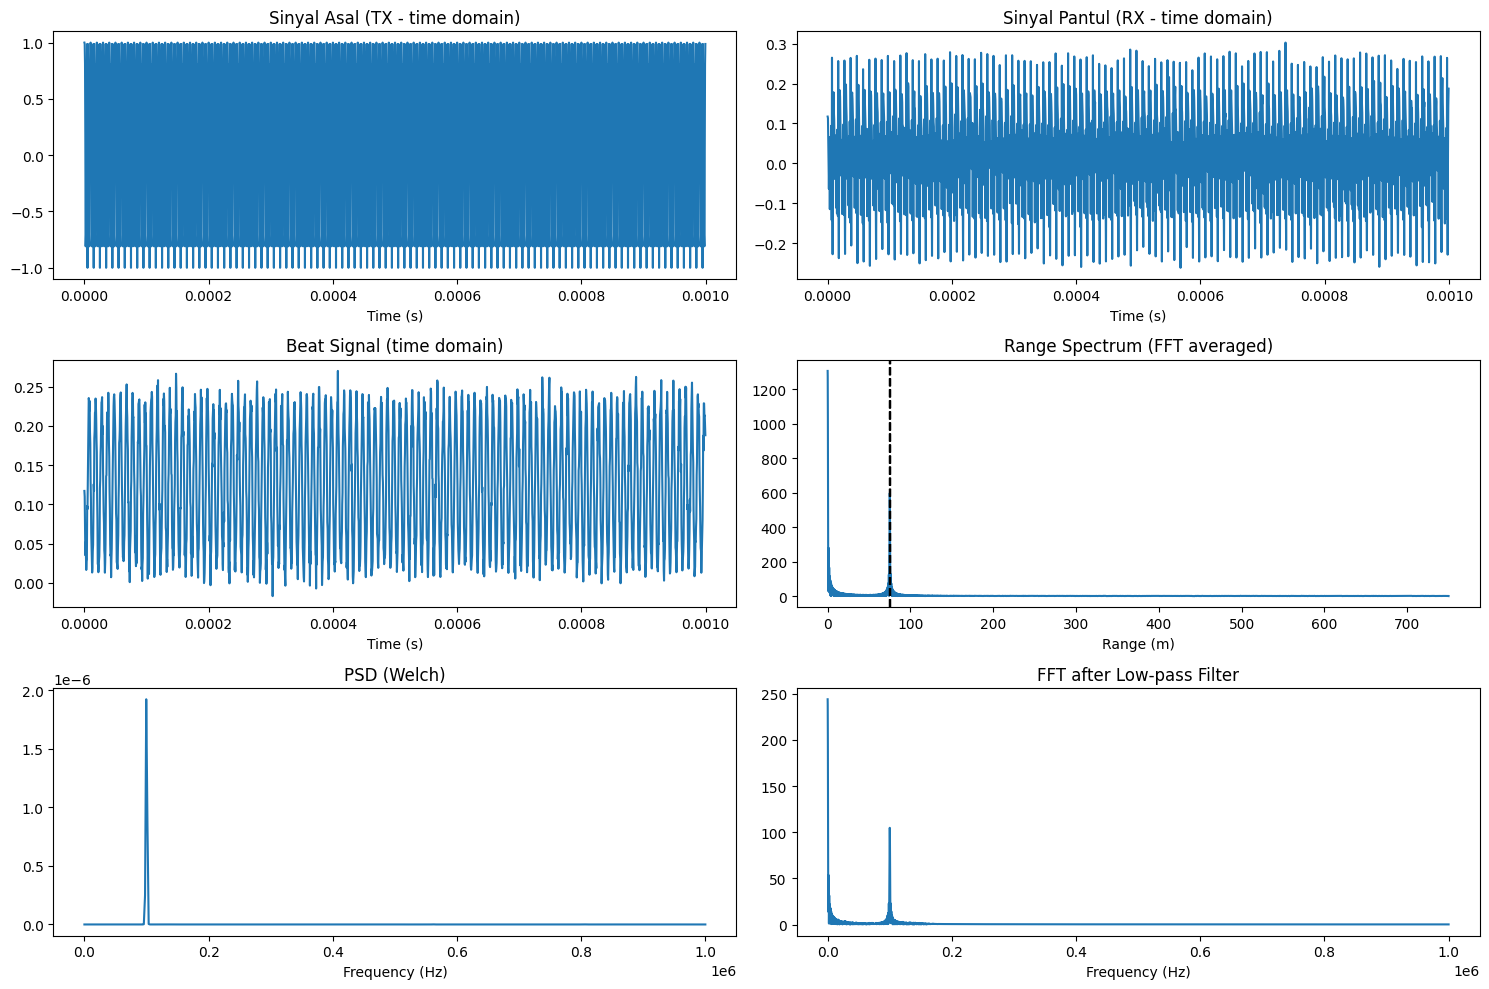

In [7]:
"""
fmcw_processing.py — versi stabil & siap plot
"""

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# =========================================================
# 1. LOAD DATASET
# =========================================================
data = np.load("fmcw_simulation_data.npz", allow_pickle=True)
t = data["t"]
tx = data["tx"]          # shape: (M, N)
rx = data["rx"]          # shape: (M, N)
beat = data["beat"]      # shape: (M, N)
fs = float(data["fs"])
B = float(data["B"])
T = float(data["T"])
f0 = float(data["f0"])
R_targets = data["R_targets"]

M, N = beat.shape

# =========================================================
# 2. CONVERT ALL SIGNALS TO 1D
# =========================================================
tx_1d = np.real(tx.mean(axis=0))
rx_1d = np.real(rx.mean(axis=0))
beat_1d = np.real(beat.mean(axis=0))

# =========================================================
# 3. RANGE-FFT AVERAGED ACROSS CHIRPS
# =========================================================
nfft = 2**14
S_accum = np.zeros(nfft//2)

for m in range(M):
    S = np.fft.fft(np.real(beat[m]), nfft)
    S_mag = np.abs(S[:nfft//2])
    S_accum += S_mag

S_mean = S_accum / M

# axes
f_axis = np.fft.fftfreq(nfft, 1/fs)[:nfft//2]
range_axis = f_axis * 3e8 * T / (2 * B)

# =========================================================
# 4. CARI PUNCAK
# =========================================================
f_min_ignore = 1e3
idx_search = np.where(f_axis >= f_min_ignore)[0]

topk = 6
sorted_idx = np.argsort(S_mean[idx_search])[-topk:][::-1]
peak_bins = idx_search[sorted_idx]

# quadratic interpolation
def quadratic_interpolation(mag, k):
    if k <= 0 or k >= len(mag) - 1:
        return k, mag[k]
    a = mag[k-1]
    b = mag[k]
    c = mag[k+1]
    denom = (a - 2*b + c)
    if denom == 0:
        return k, b

    delta = 0.5 * (a - c) / denom
    k_peak = k + delta
    peak_mag = b - 0.25 * (a - c) * delta
    return k_peak, peak_mag

est_ranges = []
est_freqs = []
est_mags = []

for b in peak_bins:
    k_loc, k_mag = quadratic_interpolation(S_mean, b)
    est_freq = (k_loc) * (fs / nfft)
    est_range = est_freq * 3e8 * T / (2 * B)
    est_ranges.append(est_range)
    est_freqs.append(est_freq)
    est_mags.append(k_mag)

# =========================================================
# 5. PSD
# =========================================================
from scipy.signal import welch, firwin, lfilter
f_welch, Pxx = welch(beat_1d, fs=fs, nperseg=1024)
use_scipy = True

# =========================================================
# 6. LOW-PASS FILTER
# =========================================================
def design_fir_lowpass(numtaps, fc_norm):
    M = numtaps - 1
    n = np.arange(0, numtaps)
    h = np.sinc(2 * fc_norm * (n - M/2))
    h *= np.hamming(numtaps)
    h /= np.sum(h)
    return h

expected_max_freq = (2 * max(R_targets) * B) / (3e8 * T)
f_cut = 1.5 * expected_max_freq
fc_norm = f_cut / (fs/2)
numtaps = 129

if use_scipy:
    h = firwin(numtaps, f_cut, fs=fs, window="hamming")
    beat_filt = lfilter(h, 1.0, beat_1d)
else:
    h = design_fir_lowpass(numtaps, fc_norm)
    beat_filt = np.convolve(beat_1d, h, mode="same")

# FFT filtered
S_filt = np.abs(np.fft.fft(beat_filt, nfft)[:nfft//2])

# =========================================================
# 7. PRINT RINGKASAN
# =========================================================
print("Ground truth ranges (m):", R_targets)
print("Estimated ranges (m):   ", np.round(est_ranges, 3))
print("Estimated beat freqs (Hz):", np.round(est_freqs, 1))

# =========================================================
# 8. PLOTTING
# =========================================================

plt.figure(figsize=(15, 10))

# ---- 1. TX & RX (Time domain) ----
plt.subplot(3, 2, 1)
plt.plot(t[:len(tx_1d)], tx_1d)
plt.title("Sinyal Asal (TX - time domain)")
plt.xlabel("Time (s)")

plt.subplot(3, 2, 2)
plt.plot(t[:len(rx_1d)], rx_1d)
plt.title("Sinyal Pantul (RX - time domain)")
plt.xlabel("Time (s)")

# ---- 2. Beat Signal ----
plt.subplot(3, 2, 3)
plt.plot(t[:len(beat_1d)], beat_1d)
plt.title("Beat Signal (time domain)")
plt.xlabel("Time (s)")

# ---- 3. Range FFT ----
plt.subplot(3, 2, 4)
plt.plot(range_axis, S_mean)
for r in est_ranges:
    plt.axvline(r, color='k', linestyle='--')
plt.title("Range Spectrum (FFT averaged)")
plt.xlabel("Range (m)")

# ---- 4. PSD ----
plt.subplot(3, 2, 5)
plt.plot(f_welch, Pxx)
plt.title("PSD (Welch)")
plt.xlabel("Frequency (Hz)")

# ---- 5. Filtered FFT ----
plt.subplot(3, 2, 6)
plt.plot(f_axis, S_filt)
plt.title("FFT after Low-pass Filter")
plt.xlabel("Frequency (Hz)")

plt.tight_layout()
plt.show()

Ground truth ranges: [30. 80.]
Estimated ranges:    [74.999 74.999 75.003 74.983 75.032 74.921]
Estimated freqs:     [ 99999.1  99998.1 100004.5  99977.4 100042.1  99895. ]


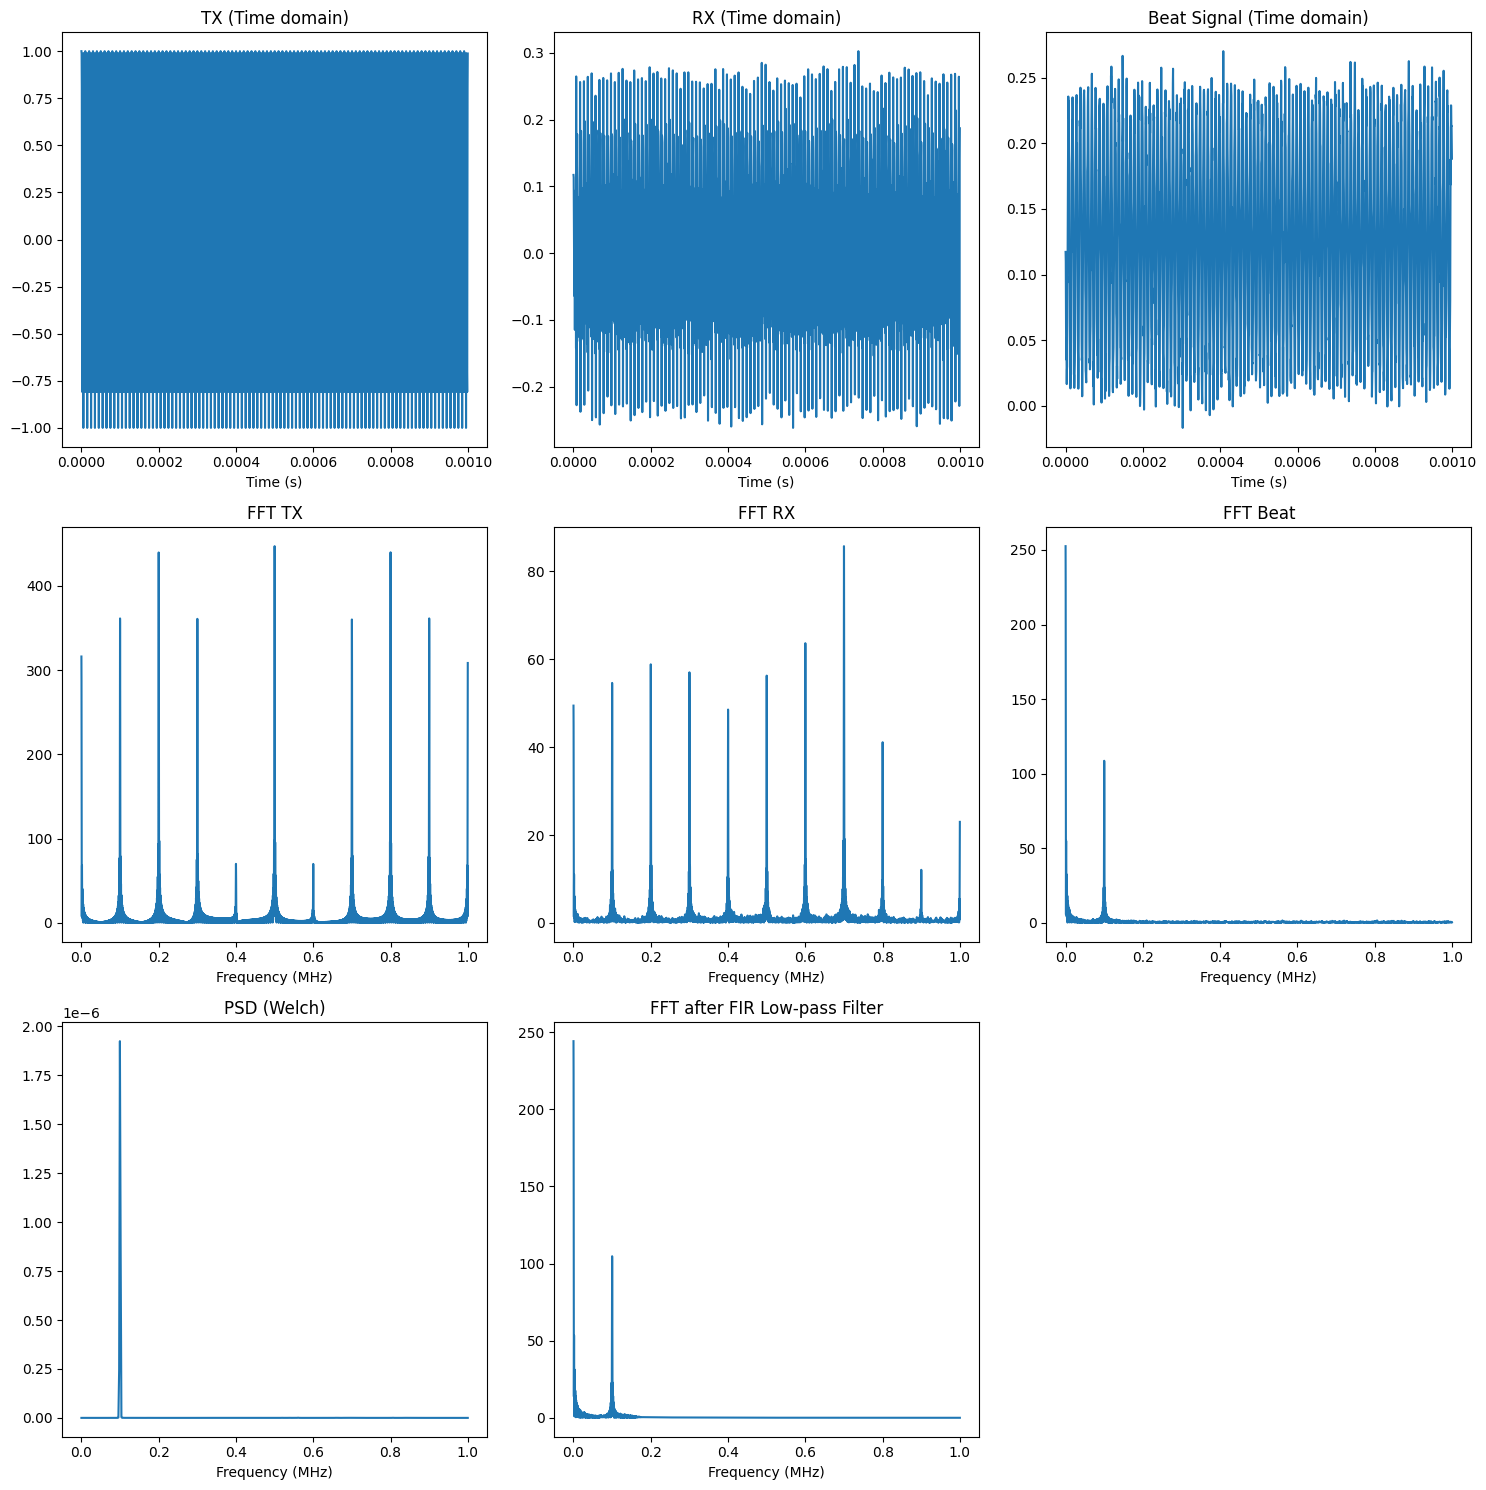

In [15]:
"""
fmcw_processing_full.py — versi lengkap + semua plot
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch, firwin, lfilter, spectrogram

# =========================================================
# 1. LOAD DATASET
# =========================================================
data = np.load("fmcw_simulation_data.npz", allow_pickle=True)
t = data["t"]
tx = data["tx"]          # (M, N)
rx = data["rx"]          # (M, N)
beat = data["beat"]      # (M, N)
fs = float(data["fs"])
B = float(data["B"])
T = float(data["T"])
f0 = float(data["f0"])
R_targets = data["R_targets"]

M, N = beat.shape

# =========================================================
# 2. CONVERT TO 1D (averaged across chirps)
# =========================================================
tx_1d = np.real(tx.mean(axis=0))
rx_1d = np.real(rx.mean(axis=0))
beat_1d = np.real(beat.mean(axis=0))

# =========================================================
# 3. FFT DEFINITIONS
# =========================================================
nfft = 2**14
f_axis = np.fft.fftfreq(nfft, 1/fs)[:nfft//2]
f_axis_Mhz = f_axis / 1e6
f_welch_Mhz = f_welch / 1e6


# FFT TX / RX / BEAT
TX_fft = np.abs(np.fft.fft(tx_1d, nfft))[:nfft//2]
RX_fft = np.abs(np.fft.fft(rx_1d, nfft))[:nfft//2]
BEAT_fft = np.abs(np.fft.fft(beat_1d, nfft))[:nfft//2]

# =========================================================
# 4. RANGE FFT AVERAGED ACROSS CHIRPS
# =========================================================
S_accum = np.zeros(nfft//2)

for m in range(M):
    S = np.fft.fft(np.real(beat[m]), nfft)
    S_mag = np.abs(S[:nfft//2])
    S_accum += S_mag

S_mean = S_accum / M
range_axis = f_axis * 3e8 * T / (2 * B)

# =========================================================
# 5. PEAK DETECTION
# =========================================================
f_min_ignore = 1e3
idx_search = np.where(f_axis >= f_min_ignore)[0]

topk = 6
sorted_idx = np.argsort(S_mean[idx_search])[-topk:][::-1]
peak_bins = idx_search[sorted_idx]

def quadratic_interpolation(mag, k):
    if k <= 0 or k >= len(mag)-1:
        return k, mag[k]
    a, b, c = mag[k-1], mag[k], mag[k+1]
    denom = (a - 2*b + c)
    if denom == 0:
        return k, b
    delta = 0.5 * (a - c) / denom
    k_peak = k + delta
    peak_mag = b - 0.25 * (a - c) * delta
    return k_peak, peak_mag

est_ranges = []
est_freqs = []

for b in peak_bins:
    k_loc, _ = quadratic_interpolation(S_mean, b)
    est_freq = k_loc * (fs / nfft)
    est_range = est_freq * 3e8 * T / (2 * B)

    est_ranges.append(est_range)
    est_freqs.append(est_freq)

# =========================================================
# 6. PSD (Welch)
# =========================================================
f_welch, Pxx = welch(beat_1d, fs=fs, nperseg=1024)

# =========================================================
# 7. FIR LOW-PASS FILTER
# =========================================================
expected_max_freq = (2 * max(R_targets) * B) / (3e8 * T)
f_cut = 1.5 * expected_max_freq
numtaps = 129
h = firwin(numtaps, f_cut, fs=fs, window="hamming")

beat_filt = lfilter(h, 1.0, beat_1d)
S_filt = np.abs(np.fft.fft(beat_filt, nfft))[:nfft//2]

# =========================================================
# 9. SUMMARY
# =========================================================
print("Ground truth ranges:", R_targets)
print("Estimated ranges:   ", np.round(est_ranges, 3))
print("Estimated freqs:    ", np.round(est_freqs, 1))

# =========================================================
# 10. PLOTTING
# =========================================================

plt.figure(figsize=(15, 15))

# ---- Time domain ----
plt.subplot(3, 3, 1)
plt.plot(t[:len(tx_1d)], tx_1d)
plt.title("TX (Time domain)")
plt.xlabel("Time (s)")
plt.xlabel("Time (s)")

plt.subplot(3, 3, 2)
plt.plot(t[:len(rx_1d)], rx_1d)
plt.title("RX (Time domain)")
plt.xlabel("Time (s)")

plt.subplot(3, 3, 3)
plt.plot(t[:len(beat_1d)], beat_1d)
plt.title("Beat Signal (Time domain)")
plt.xlabel("Time (s)")

# ---- FFT Domain ----
plt.subplot(3, 3, 4)
plt.plot(f_axis_Mhz, TX_fft)
plt.title("FFT TX")
plt.xlabel("Frequency (MHz)")

plt.subplot(3, 3, 5)
plt.plot(f_axis_Mhz, RX_fft)
plt.title("FFT RX")
plt.xlabel("Frequency (MHz)")

plt.subplot(3, 3, 6)
plt.plot(f_axis_Mhz, BEAT_fft)
plt.title("FFT Beat")
plt.xlabel("Frequency (MHz)")

# ---- PSD ----
plt.subplot(3, 3, 7)
plt.plot(f_welch_Mhz, Pxx)
plt.title("PSD (Welch)")
plt.xlabel("Frequency (MHz)")

# ---- FIR filtered ----
plt.subplot(3, 3, 8)
plt.plot(f_axis_Mhz, S_filt)
plt.title("FFT after FIR Low-pass Filter")
plt.xlabel("Frequency (MHz)")

plt.tight_layout()
plt.show()